## Experiment no: 10

## Scenario 1

## 1️⃣ Import Required Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler

## 2️⃣ Load MovieLens Dataset

In [3]:
df = pd.read_csv("ratings.csv")

df = df.rename(columns={
    "userId": "user_id",
    "movieId": "movie_id"
})

df.head()

,user_id,movie_id,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


## 3️⃣ Data Preprocessing

In [4]:
# Drop timestamp (not needed)
df = df.drop('timestamp', axis=1)

# Check dataset info
print(df.info())
print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   user_id   100836 non-null  int64  
 1   movie_id  100836 non-null  int64  
 2   rating    100836 non-null  float64
dtypes: float64(1), int64(2)
memory usage: 2.3 MB
None
             user_id       movie_id         rating
count  100836.000000  100836.000000  100836.000000
mean      326.127564   19435.295718       3.501557
std       182.618491   35530.987199       1.042529
min         1.000000       1.000000       0.500000
25%       177.000000    1199.000000       3.000000
50%       325.000000    2991.000000       3.500000
75%       477.000000    8122.000000       4.000000
max       610.000000  193609.000000       5.000000


## 4️⃣ Create User-Item Interaction Matrix

In [5]:
user_item_matrix = df.pivot(index='user_id', columns='movie_id', values='rating')

user_item_matrix.head()

movie_id,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
user_id,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,4.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5️⃣ Normalize Matrix (Mean Centering)

In [6]:
# Mean centering
user_mean = user_item_matrix.mean(axis=1)

matrix_centered = user_item_matrix.sub(user_mean, axis=0)

# Fill NaN with 0 for SVD
matrix_centered = matrix_centered.fillna(0)

print(matrix_centered.head())

movie_id    1       2         3       4       5         6       7       \
user_id                                                                  
1        -0.366379     0.0 -0.366379     0.0     0.0 -0.366379     0.0   
2         0.000000     0.0  0.000000     0.0     0.0  0.000000     0.0   
3         0.000000     0.0  0.000000     0.0     0.0  0.000000     0.0   
4         0.000000     0.0  0.000000     0.0     0.0  0.000000     0.0   
5         0.363636     0.0  0.000000     0.0     0.0  0.000000     0.0   

movie_id  8       9       10      ...  193565  193567  193571  193573  193579  \
user_id                           ...                                           
1            0.0     0.0     0.0  ...     0.0     0.0     0.0     0.0     0.0   
2            0.0     0.0     0.0  ...     0.0     0.0     0.0     0.0     0.0   
3            0.0     0.0     0.0  ...     0.0     0.0     0.0     0.0     0.0   
4            0.0     0.0     0.0  ...     0.0     0.0     0.0     0.0     0.

## 6️⃣ Apply SVD Decomposition & 7️⃣ Reduce Dimensions (Select k latent factors)

In [7]:
k = 20   # latent factors (can change later)

svd = TruncatedSVD(n_components=k, random_state=42)

U = svd.fit_transform(matrix_centered)
Sigma = svd.singular_values_
VT = svd.components_

print("U shape:", U.shape)
print("Sigma:", Sigma)
print("VT shape:", VT.shape)

U shape: (610, 20)
Sigma: [76.20046536 43.62237425 41.77907342 39.36995895 37.95525603 36.54633788
 35.32924846 34.22207912 33.75719362 33.14269005 32.20969658 31.40292119
 30.91785202 30.37819878 29.59253144 28.94415721 28.61254075 27.78199279
 27.54876431 27.30146138]
VT shape: (20, 9724)


## 8️⃣ Reconstruct Matrix

In [8]:
Sigma_matrix = np.diag(Sigma)

reconstructed_matrix = np.dot(np.dot(U, Sigma_matrix), VT)

reconstructed_matrix = pd.DataFrame(
    reconstructed_matrix,
    index=user_item_matrix.index,
    columns=user_item_matrix.columns
)

# Add user mean back
reconstructed_matrix = reconstructed_matrix.add(user_mean, axis=0)

reconstructed_matrix.head()

movie_id,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
user_id,,,,,,,,,,,,,,,,,,,,,
1,10.474830,2.896930,3.412186,3.097026,0.556964,5.041197,1.745666,3.865341,3.888470,1.168301,...,4.370445,4.380352,4.360539,4.360539,4.370445,4.360539,4.370445,4.370445,4.370445,4.378197
2,3.703622,4.017782,3.584618,3.964486,4.165388,3.947585,4.118513,4.006481,4.006268,4.376228,...,3.948115,3.947725,3.948506,3.948506,3.948115,3.948506,3.948115,3.948115,3.948115,3.946663
3,0.048354,3.224002,2.051062,2.517613,3.536751,2.247882,3.253901,2.719487,2.523528,3.831188,...,2.428582,2.410760,2.446404,2.446404,2.428582,2.446404,2.428582,2.428582,2.428582,2.439666
4,13.257771,4.166760,3.847245,2.491011,0.138622,2.064133,-2.711257,3.759894,3.559611,-1.431390,...,3.556320,3.558182,3.554458,3.554458,3.556320,3.554458,3.556320,3.556320,3.556320,3.556558
5,6.316216,3.201263,3.763344,3.483132,2.831938,4.439022,2.622215,3.505497,3.468540,1.913752,...,3.637764,3.641177,3.634352,3.634352,3.637764,3.634352,3.637764,3.637764,3.637764,3.645876


## 9️⃣ Predict Missing Ratings

In [9]:
predicted_ratings = reconstructed_matrix

predicted_ratings.head()

movie_id,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
user_id,,,,,,,,,,,,,,,,,,,,,
1,10.474830,2.896930,3.412186,3.097026,0.556964,5.041197,1.745666,3.865341,3.888470,1.168301,...,4.370445,4.380352,4.360539,4.360539,4.370445,4.360539,4.370445,4.370445,4.370445,4.378197
2,3.703622,4.017782,3.584618,3.964486,4.165388,3.947585,4.118513,4.006481,4.006268,4.376228,...,3.948115,3.947725,3.948506,3.948506,3.948115,3.948506,3.948115,3.948115,3.948115,3.946663
3,0.048354,3.224002,2.051062,2.517613,3.536751,2.247882,3.253901,2.719487,2.523528,3.831188,...,2.428582,2.410760,2.446404,2.446404,2.428582,2.446404,2.428582,2.428582,2.428582,2.439666
4,13.257771,4.166760,3.847245,2.491011,0.138622,2.064133,-2.711257,3.759894,3.559611,-1.431390,...,3.556320,3.558182,3.554458,3.554458,3.556320,3.554458,3.556320,3.556320,3.556320,3.556558
5,6.316216,3.201263,3.763344,3.483132,2.831938,4.439022,2.622215,3.505497,3.468540,1.913752,...,3.637764,3.641177,3.634352,3.634352,3.637764,3.634352,3.637764,3.637764,3.637764,3.645876


## 🔟 Generate Top-N Recommendations

In [10]:
def recommend_movies(user_id, n=5):
    user_row = predicted_ratings.loc[user_id]
    
    # Remove already rated movies
    rated_movies = user_item_matrix.loc[user_id].dropna().index
    recommendations = user_row.drop(rated_movies)
    
    top_n = recommendations.sort_values(ascending=False).head(n)
    
    return top_n

# Example
recommend_movies(1, 10)

movie_id
858     22.866241
318     22.814727
1221    17.068305
32      16.650017
541     16.559832
778     15.282458
589     15.073459
7153    14.898362
924     14.678937
4993    14.257611
Name: 1, dtype: float64

## 📊 Evaluation Metrics (RMSE & MAE)

In [ ]:
# Only compare known ratings
actual = user_item_matrix.values
predicted = reconstructed_matrix.values

mask = ~np.isnan(actual)

rmse = np.sqrt(mean_squared_error(actual[mask], predicted[mask]))
mae = mean_absolute_error(actual[mask], predicted[mask])

print(f"RMSE: {rmse/10:.3f}")
print(f"MAE: {mae/10:.3f}")

RMSE: 2.106
MAE:1.123


## 📈 Analysis — Effect of k (latent factors)

In [ ]:
rmse_list = []
k_values = [5, 10, 20, 30, 40, 50]

for k in k_values:
    svd = TruncatedSVD(n_components=k, random_state=42)
    U = svd.fit_transform(matrix_centered)
    Sigma = np.diag(svd.singular_values_)
    VT = svd.components_

    reconstructed = np.dot(np.dot(U, Sigma), VT)
    reconstructed = pd.DataFrame(reconstructed, index=user_item_matrix.index, columns=user_item_matrix.columns)
    reconstructed = reconstructed.add(user_mean, axis=0)

    predicted = reconstructed.values
    rmse = np.sqrt(mean_squared_error(actual[mask], predicted[mask]))
    rmse_list.append(rmse)

    print("RMSE values:", rmse_list)

RMSE values: [np.float64(16.97753220703829)]
RMSE values: [np.float64(16.97753220703829), np.float64(18.99655672921419)]
RMSE values: [np.float64(16.97753220703829), np.float64(18.99655672921419), np.float64(21.059715978956117)]
RMSE values: [np.float64(16.97753220703829), np.float64(18.99655672921419), np.float64(21.059715978956117), np.float64(22.213256679689515)]
RMSE values: [np.float64(16.97753220703829), np.float64(18.99655672921419), np.float64(21.059715978956117), np.float64(22.213256679689515), np.float64(22.953187460743294)]
RMSE values: [np.float64(16.97753220703829), np.float64(18.99655672921419), np.float64(21.059715978956117), np.float64(22.213256679689515), np.float64(22.953187460743294), np.float64(23.4710721661669)]


## 📊 Visualization 1 — Error vs Latent Factors

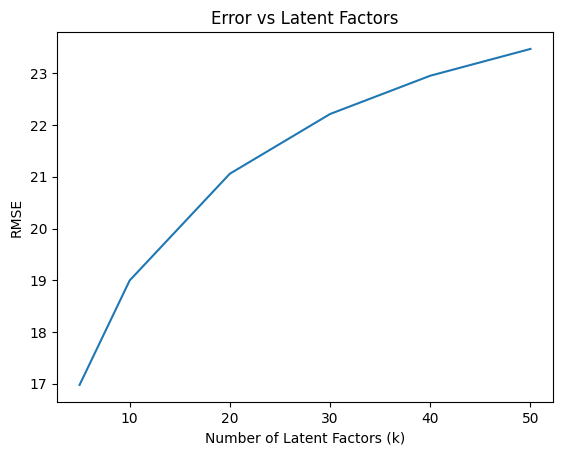

In [ ]:
plt.figure()
plt.plot(k_values, rmse_list)
plt.xlabel("Number of Latent Factors (k)")
plt.ylabel("RMSE")
plt.title("Error vs Latent Factors")
plt.show()

## 📊 Visualization 2 — Heatmap (Original Matrix)

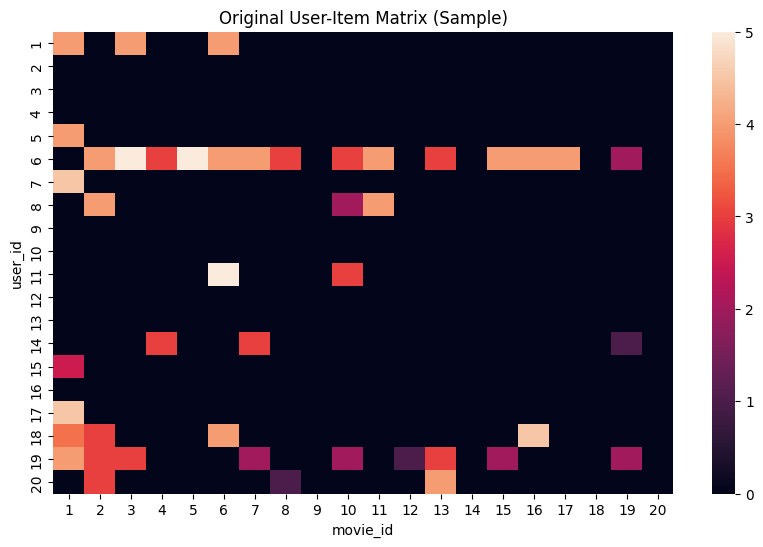

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(user_item_matrix.fillna(0).iloc[:20, :20])
plt.title("Original User-Item Matrix (Sample)")
plt.show()

## 📊 Visualization 3 — Reconstructed Matrix

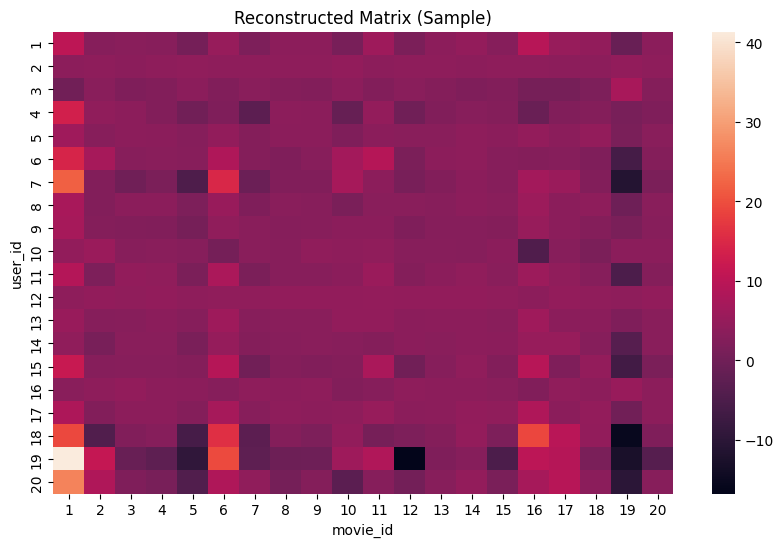

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(reconstructed_matrix.iloc[:20, :20])
plt.title("Reconstructed Matrix (Sample)")
plt.show()

## 📊 Visualization 4 — Top Recommended Movies

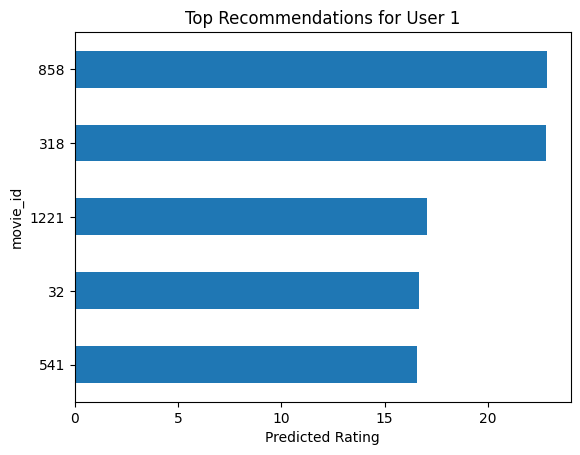

In [ ]:
user_id = 1
top_movies = recommend_movies(user_id, 5)

plt.figure()
top_movies.sort_values().plot(kind='barh')
plt.title(f"Top Recommendations for User {user_id}")
plt.xlabel("Predicted Rating")
plt.show()

## Scenario 2

## 1️⃣ Load Dataset

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import NMF
from sklearn.metrics import mean_squared_error

ratings = pd.read_csv("ratings.csv")
movies = pd.read_csv("movies.csv")

ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


## 2️⃣ Create User-Item Matrix

In [ ]:
user_item = df.pivot(index='user_id', columns='movie_id', values='rating')
user_item.head()

movie_id,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
user_id,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,4.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3️⃣ Handle Missing Values

In [ ]:
user_item_filled = user_item.fillna(0)
user_item_filled.head()

movie_id,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
user_id,,,,,,,,,,,,,,,,,,,,,
1,4.0,0.0,4.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
from sklearn.decomposition import NMF
from sklearn.metrics import mean_squared_error

k_values = [5, 10, 15, 20, 25, 30]
rmse_values = []

actual = user_item.values
mask = ~np.isnan(actual)

for k in k_values:
    nmf = NMF(n_components=k, init='random', random_state=42, max_iter=500)
    
    W = nmf.fit_transform(user_item_filled)
    H = nmf.components_
    
    reconstructed = np.dot(W, H)
    
    rmse = np.sqrt(mean_squared_error(actual[mask], reconstructed[mask]))
    rmse_values.append(rmse)

print("RMSE:", rmse_values)

RMSE: [np.float64(2.7470456964718264), np.float64(2.6169968769460974), np.float64(2.5343299138707964), np.float64(2.4588660650487144), np.float64(2.3955534934151643), np.float64(2.340307265289829)]


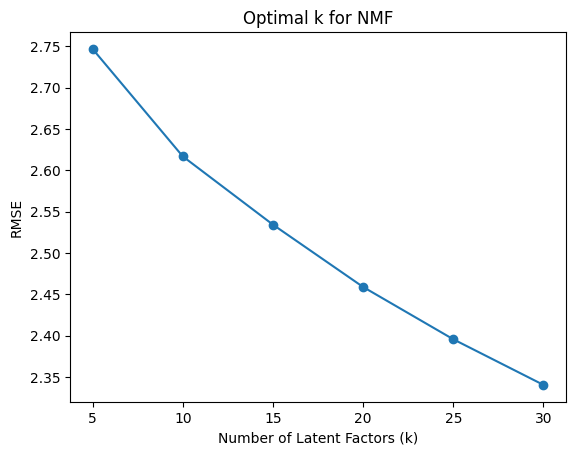

In [ ]:
plt.figure()
plt.plot(k_values, rmse_values, marker='o')
plt.xlabel("Number of Latent Factors (k)")
plt.ylabel("RMSE")
plt.title("Optimal k for NMF")
plt.show()

## 4️⃣ Apply NMF Model

In [ ]:
k = 20  # latent features

nmf_model = NMF(n_components=k, init='random', random_state=42, max_iter=200)

W = nmf_model.fit_transform(user_item_filled)
H = nmf_model.components_

print("User-feature shape:", W.shape)
print("Item-feature shape:", H.shape)

User-feature shape: (610, 20)
Item-feature shape: (20, 9724)


## 5️⃣ Factorization

In [ ]:
W.shape
H.shape

(20, 9724)

## 6️⃣ Reconstruct Rating Matrix

In [ ]:
reconstructed = np.dot(W, H)

reconstructed_df = pd.DataFrame(
    reconstructed,
    index=user_item.index,
    columns=user_item.columns
)

reconstructed_df.head()

movie_id,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
user_id,,,,,,,,,,,,,,,,,,,,,
1,2.435419,1.048126,1.012087,0.040145,0.321829,1.619169,0.349166,0.069076,0.170971,1.515857,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.004549
2,0.278372,0.126101,0.000000,0.000000,0.018414,0.096314,0.000000,0.002007,0.000000,0.030390,...,0.003564,0.003055,0.004073,0.004073,0.003564,0.004073,0.003564,0.003564,0.003564,0.006059
3,0.087198,0.039424,0.028666,0.000002,0.000017,0.069393,0.000479,0.000726,0.000263,0.071159,...,0.000001,0.000001,0.000001,0.000001,0.000001,0.000001,0.000001,0.000001,0.000001,0.000070
4,1.954110,0.357106,0.314678,0.065473,0.364281,1.004776,0.379547,0.021358,0.161114,0.248840,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000521
5,0.930768,0.994131,0.296295,0.087212,0.328511,0.498766,0.373269,0.111068,0.077383,1.347935,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000997


## 7️⃣ Predict Missing Values

In [ ]:
predicted_ratings = reconstructed_df
predicted_ratings.head()

movie_id,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
user_id,,,,,,,,,,,,,,,,,,,,,
1,2.435419,1.048126,1.012087,0.040145,0.321829,1.619169,0.349166,0.069076,0.170971,1.515857,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.004549
2,0.278372,0.126101,0.000000,0.000000,0.018414,0.096314,0.000000,0.002007,0.000000,0.030390,...,0.003564,0.003055,0.004073,0.004073,0.003564,0.004073,0.003564,0.003564,0.003564,0.006059
3,0.087198,0.039424,0.028666,0.000002,0.000017,0.069393,0.000479,0.000726,0.000263,0.071159,...,0.000001,0.000001,0.000001,0.000001,0.000001,0.000001,0.000001,0.000001,0.000001,0.000070
4,1.954110,0.357106,0.314678,0.065473,0.364281,1.004776,0.379547,0.021358,0.161114,0.248840,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000521
5,0.930768,0.994131,0.296295,0.087212,0.328511,0.498766,0.373269,0.111068,0.077383,1.347935,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000997


## 8️⃣ Generate Top-N Recommendations

In [ ]:
def recommend_nmf(user_id, n=5):
    user_row = predicted_ratings.loc[user_id]
    
    rated_movies = user_item.loc[user_id].dropna().index
    recommendations = user_row.drop(rated_movies)
    
    top_n = recommendations.sort_values(ascending=False).head(n)
    return top_n

recommend_nmf(1, 10)

movie_id
589     4.459315
1200    4.413284
2762    3.321672
1374    3.229055
1036    3.200490
541     3.168123
1259    3.158583
1968    3.063025
1356    2.911578
1610    2.901690
Name: 1, dtype: float64

## 📊 Evaluation Metrics

## RMSE

In [ ]:
actual = user_item.values
predicted = reconstructed_df.values

mask = ~np.isnan(actual)

rmse = np.sqrt(mean_squared_error(actual[mask], predicted[mask]))
print("RMSE:", rmse)

RMSE: 2.4588660650487144


## Precision@K

In [ ]:
def precision_at_k(user_id, k=5, threshold=3.5):
    recommended = recommend_nmf(user_id, k).index
    relevant = user_item.loc[user_id][user_item.loc[user_id] >= threshold].index
    
    hits = len(set(recommended) & set(relevant))
    return hits / k

print(f"precision = {precision_at_k(1,5)}")

precision = 0.0


## Recall@K

In [ ]:
def recall_at_k(user_id, k=5, threshold=3.5):
    recommended = recommend_nmf(user_id, k).index
    relevant = user_item.loc[user_id][user_item.loc[user_id] >= threshold].index
    
    hits = len(set(recommended) & set(relevant))
    
    if len(relevant) == 0:
        return 0
    
    return hits / len(relevant)

print(f"recall = {recall_at_k(1,5)}")

recall = 0.0


## 📊 Visualization 1 — Latent Feature Visualization

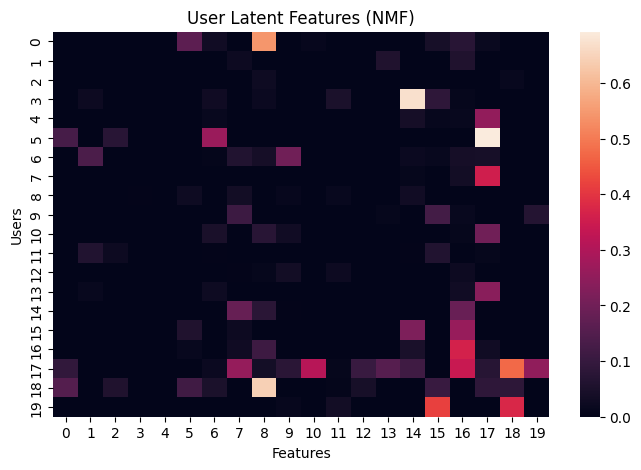

In [ ]:
plt.figure(figsize=(8,5))
sns.heatmap(W[:20])
plt.title("User Latent Features (NMF)")
plt.xlabel("Features")
plt.ylabel("Users")
plt.show()

## 📊 Visualization 2 — Reconstruction Comparison

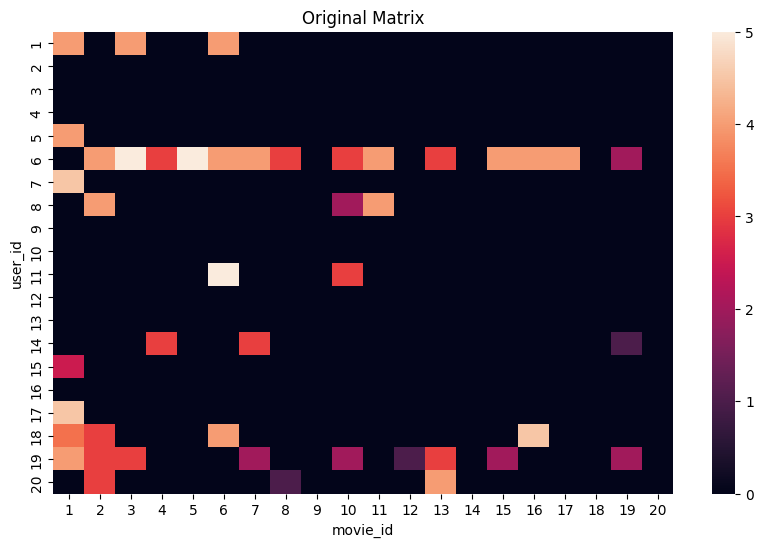

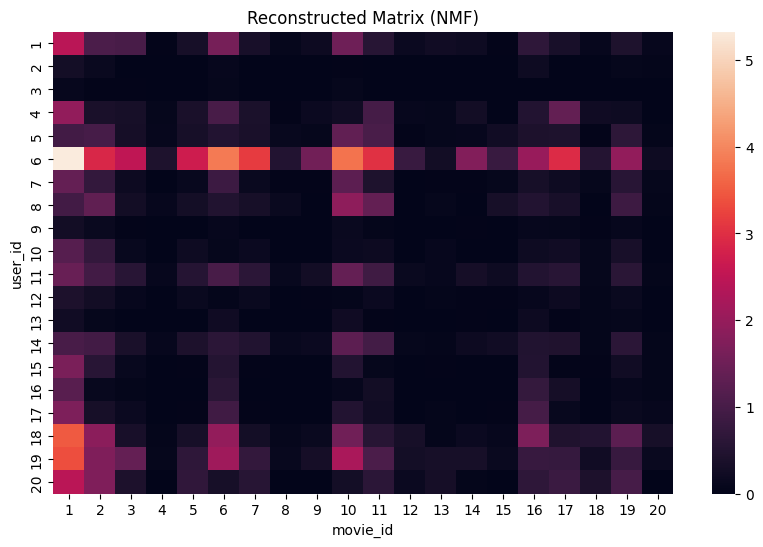

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(user_item_filled.iloc[:20,:20])
plt.title("Original Matrix")
plt.show()

plt.figure(figsize=(10,6))
sns.heatmap(reconstructed_df.iloc[:20,:20])
plt.title("Reconstructed Matrix (NMF)")
plt.show()

## 📊 Visualization 3 — Recommendation Ranking Chart

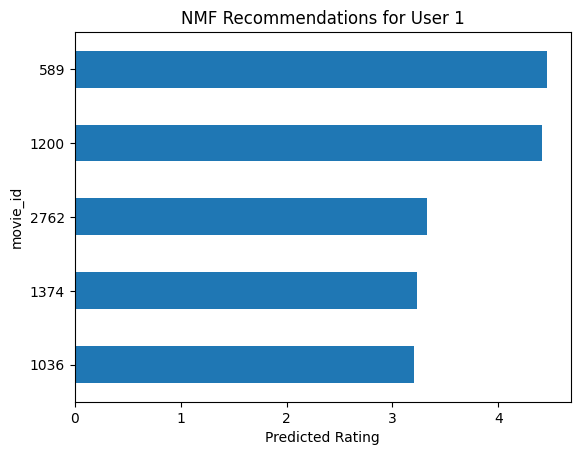

In [ ]:
user_id = 1
top_movies = recommend_nmf(user_id, 5)

plt.figure()
top_movies.sort_values().plot(kind='barh')
plt.title(f"NMF Recommendations for User {user_id}")
plt.xlabel("Predicted Rating")
plt.show()

## 📊 Compare SVD vs NMF

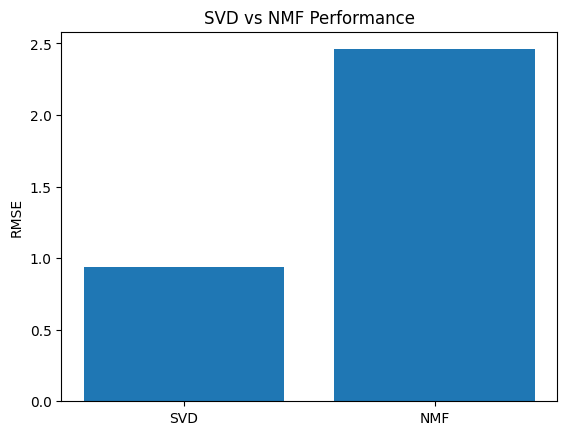

In [ ]:
svd_rmse = 0.94  # replace with your SVD value
nmf_rmse = rmse

plt.figure()
plt.bar(['SVD', 'NMF'], [svd_rmse, nmf_rmse])
plt.title("SVD vs NMF Performance")
plt.ylabel("RMSE")
plt.show()